In [ ]:
!pip install git+https://github.com/Starlitnightly/dynamo-release.git

In [1]:
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
print(f'dynamo version: {dyn.__version__}')

%load_ext autoreload
%autoreload 2

dynamo version: 1.4.4rc1


In [2]:
dyn.pl.style()



 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



In [4]:
adata=dyn.sample_data.pancreatic_endocrinogenesis()
adata

|-----> Downloading data to ./data/endocrinogenesis_day15.h5ad
|-----> File ./data/endocrinogenesis_day15.h5ad already exists.


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [5]:
adata.layers['counts']=adata.X.copy()

In [6]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(adata, recipe='monocle')

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 0 outlier cells
|-----------> filtered out 21736 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [191.3033s]
|-----> [Cell Cycle Scores Estimation] completed [0.2822s]
|-----> [Preprocessor-monocle] completed [4.3389s]

╭─ SUMMARY: Preprocessor.preprocess_adata ───────────────────────────╮
│  Duration: 4.3407s                                                 │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ Size_Factor (float)                                  │
│           │ ✚ cell_cycle_phase (category)                          │
│           │

In [7]:
#dyn.tl.dynamics(adata, model='stochastic', cores=3) 
# or dyn.tl.dynamics(adata, model='deterministic')
dyn.tl.dynamics(adata, #filter_gene_mode='basic',
                model='auto', est_method='auto',
                #sanity_check=True,
               cores=8)


|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----> [moments calculation] completed [18.3545s]

╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 25.0876s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                            

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_m', 'log_cv', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'history_log', 'vel_params_names', 'dynamics'
    obsm: 'X_pca', 'X_umap', 'cell_cycle_scores'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'counts', 'X_unspliced', 'X_counts', 'X_spliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', '

In [7]:
adata.uns['dynamics']

{'filter_gene_mode': 'final',
 't': None,
 'group': None,
 'X_data': None,
 'X_fit_data': None,
 'asspt_mRNA': 'ss',
 'experiment_type': 'conventional',
 'normalized': True,
 'model': 'stochastic',
 'est_method': 'gmm',
 'has_splicing': True,
 'has_labeling': False,
 'splicing_labeling': False,
 'has_protein': False,
 'use_smoothed': True,
 'NTR_vel': False,
 'log_unnormalized': True,
 'fraction_for_deg': False}

|-----> retrieve data for non-linear dimension reduction...
|-----? adata already have basis umap. dimension reduction umap will be skipped! 
set enforce=True to re-performing dimension reduction.
|-----> [UMAP] completed [0.0015s]

╭─ SUMMARY: reduceDimension ─────────────────────────────────────────╮
│  Duration: 0.0036s                                                 │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


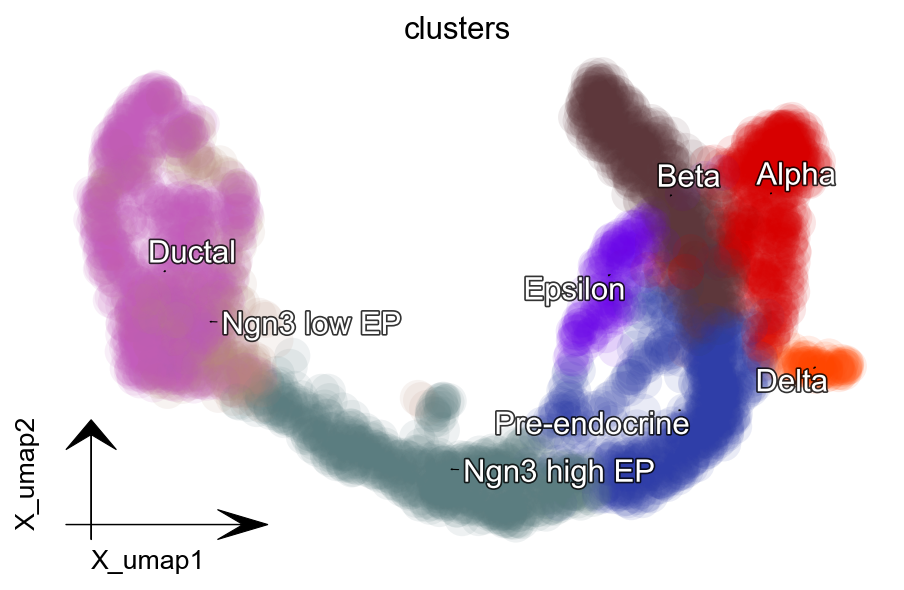

In [8]:
dyn.tl.reduceDimension(adata)

dyn.pl.umap(adata, color='clusters',
           save_show_or_return='show',
            adjust_legend=True)

In [9]:
dyn.tl.cell_velocities(adata, method='pearson', 
                       other_kernels_dict={'transform': 'sqrt'}
                      )

|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [1.4750s]
|-----> [projecting velocity vector to low dimensional embedding] completed [0.3924s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 2.886s                                                  │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_transition (bool)                            │
│                                                                    │
│  ● UNS    │ ✚ grid_velocity_umap                                   │
│                                                                    │
│  

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_m', 'log_cv', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'history_log', 'vel_params_names', 'dynamics', 'grid_velocity_umap'
    obsm: 'X_pca', 'X_umap', 'cell_cycle_scores', 'velocity_umap'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'counts', 'X_unspliced', 'X_

|-----> X shape: (3696, 2) V shape: (3696, 2)
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


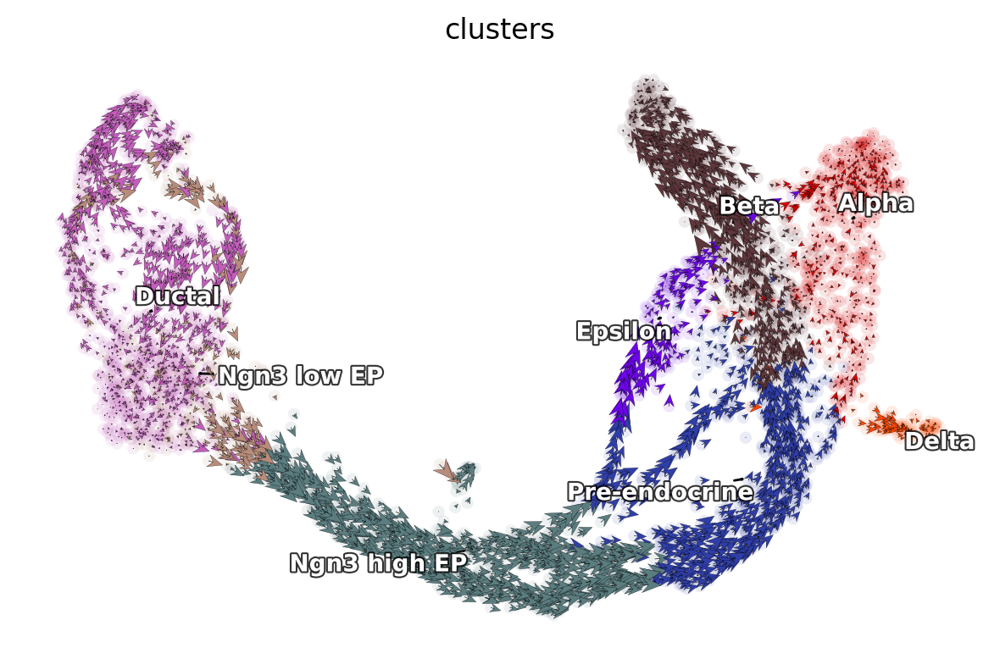

In [9]:
dyn.pl.cell_wise_vectors(adata, color=['clusters'], basis='umap', 
                         show_legend='on data', quiver_length=6, 
                         quiver_size=6, pointsize=0.1, 
                         s_kwargs_dict={'adjust_legend':True},
                         show_arrowed_spines=False)


|-----> X shape: (3696, 2) V shape: (3696, 2)
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


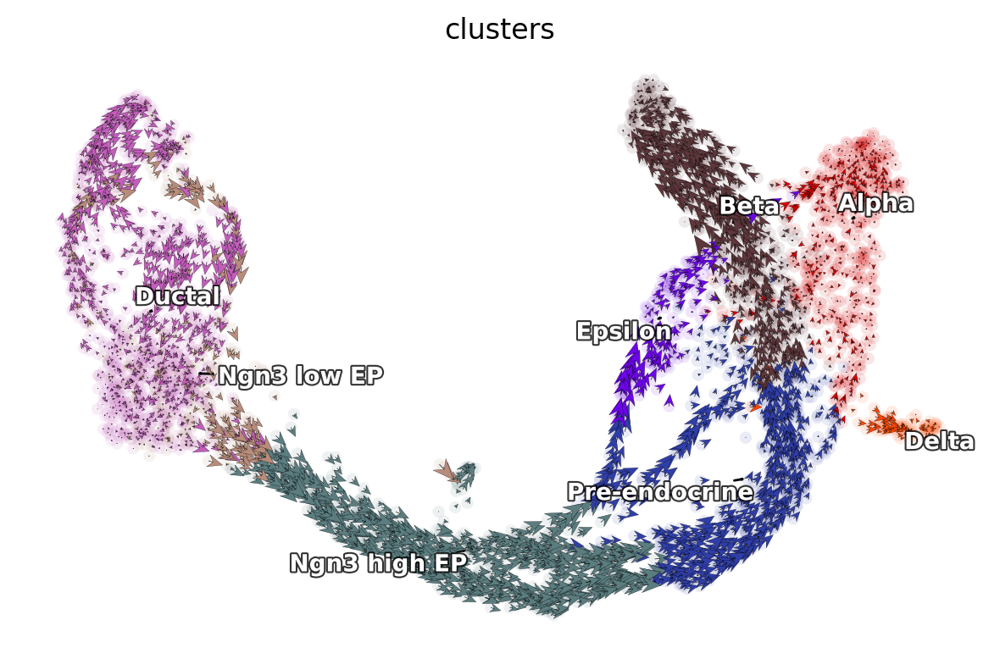

In [10]:
dyn.pl.cell_wise_vectors(adata, color=['clusters'], basis='umap', 
                         show_legend='on data', quiver_length=6, 
                         quiver_size=6, pointsize=0.1, 
                         s_kwargs_dict={'adjust_legend':True},
                         show_arrowed_spines=False)


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


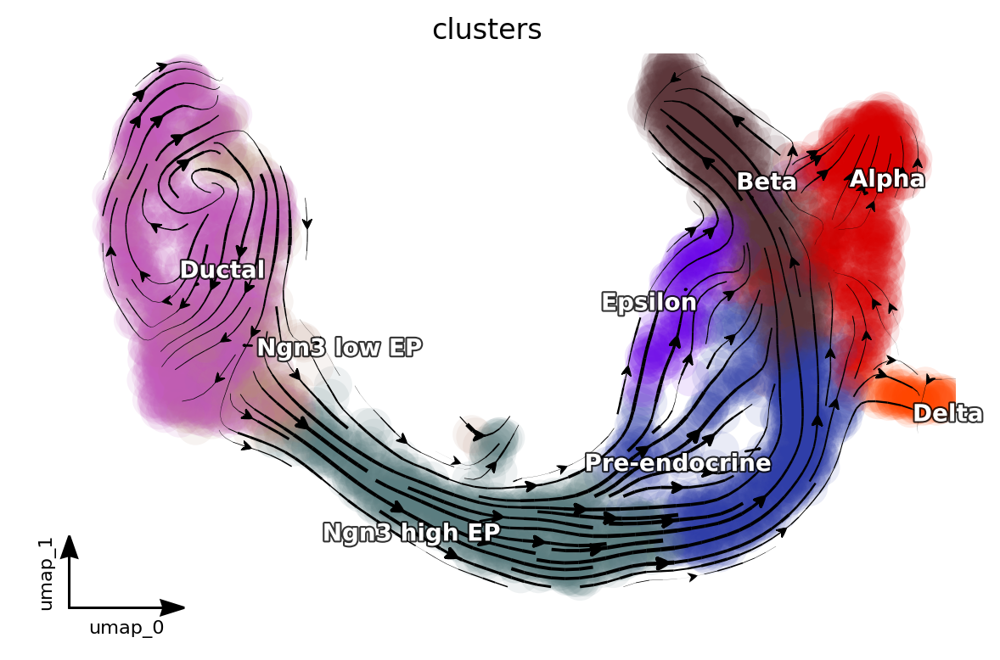

In [11]:
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap


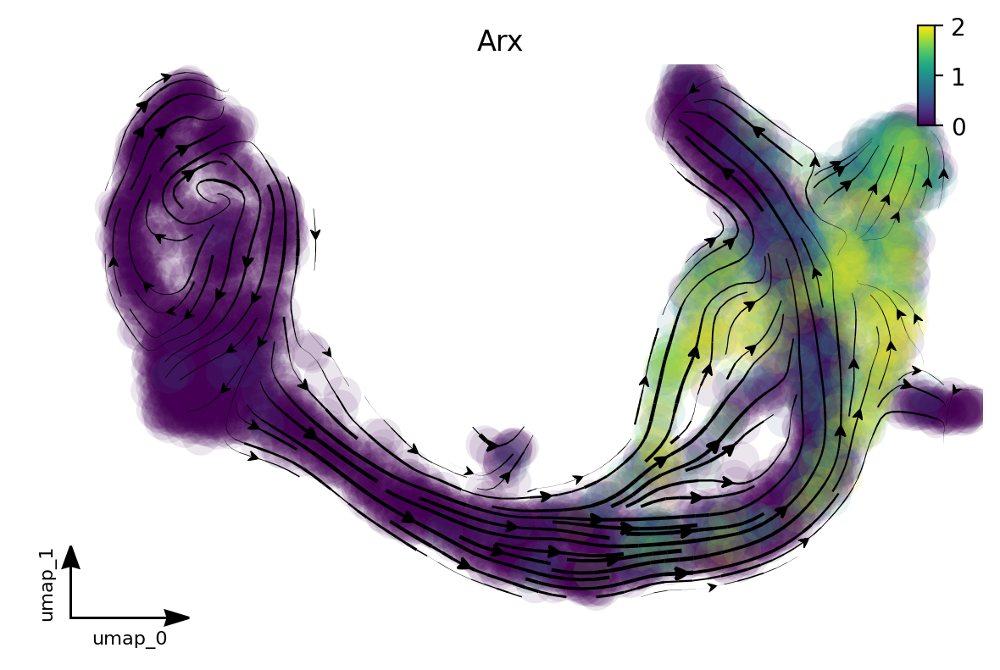

In [12]:
dyn.pl.streamline_plot(adata, color=['Arx'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap


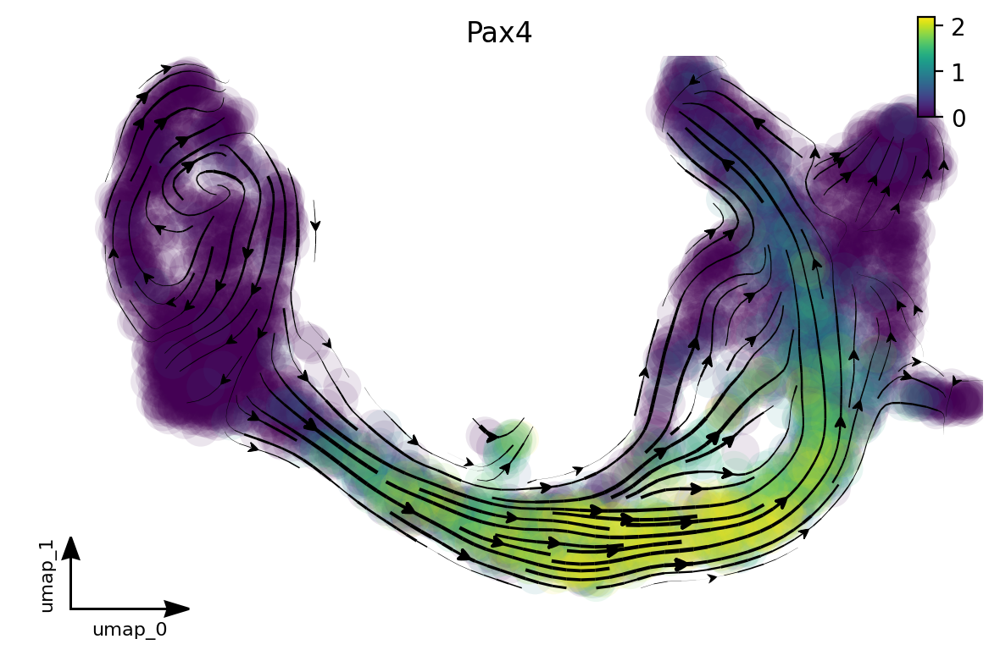

In [13]:
dyn.pl.streamline_plot(adata, color=['Pax4'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


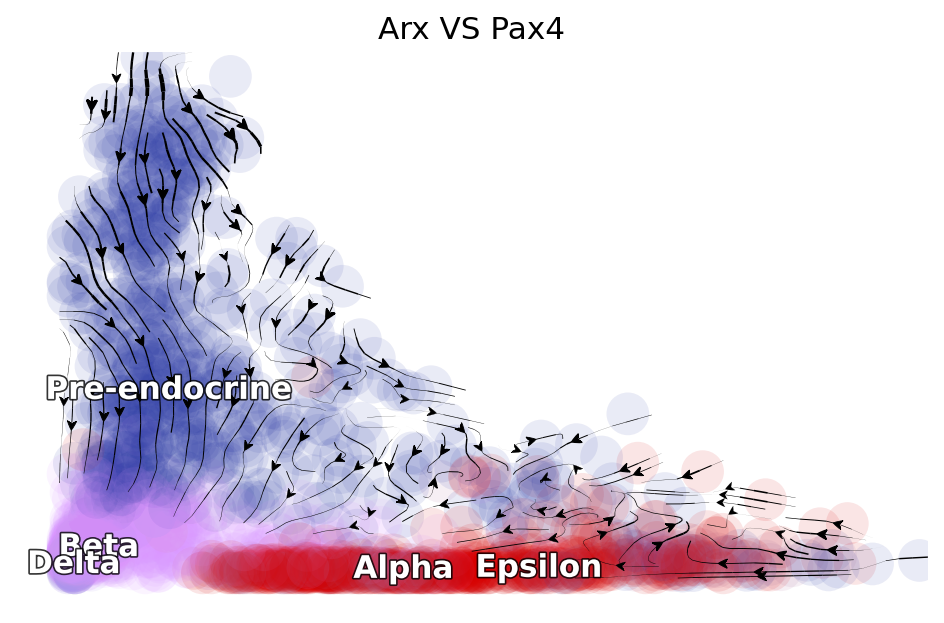

In [14]:
%matplotlib inline
dyn.pl.style()
dyn.pl.streamline_plot(
    adata[adata.obs['clusters'].isin([
        'Pre-endocrine','Alpha','Beta','Epsilon','Delta'
    ])],
    color="clusters",
    x="Arx",
    y="Pax4",
    layer="M_s",
    ekey="M_s",
    #vkey="velocity_alpha_minus_gamma_s",
)

In [11]:
dyn.vf.VectorField(adata, basis='umap', 
                   cores=12,map_topography=True,
                   pot_curl_div=True) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [55.8869s]
|-----> Mapping topography...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> Running ddhodge to estimate vector field based pseudotime in umap basis...
|-----> graphizing vectorfield...
|-----> incomplete neighbor graph info detected: connectivities and distances do not exist in adata.obsp, indices not in adata.uns.neighbors.
|-----> Neighbor graph is broken, recomputing....
|-----> Start computing neighbor graph...
|---

Calculating 2-D curl: 100%|██████████| 3696/3696 [00:00<00:00, 41748.08it/s]

|-----> Computing divergence...




alculating divergence: 100%|██████████| 4/4 [00:00<00:00, 55.91it/s]

|-----> [VectorField] completed [67.9677s]

╭─ SUMMARY: VectorField ─────────────────────────────────────────────╮
│  Duration: 67.97s                                                  │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ control_point_umap (bool)                            │
│           │ ✚ curl_umap (float)                                    │
│           │ ✚ divergence_umap (float)                              │
│           │ ✚ inlier_prob_umap (float)                             │
│           │ ✚ obs_vf_angle_umap (float)                            │
│           │ ✚ umap_ddhodge_div (float)                             │
│           │ ✚ umap_ddhodge_potential (float)                       │
│                                

In [18]:
adata.write('test.h5ad')

In [3]:
adata=dyn.read('test.h5ad')

In [4]:
dyn.vf.VectorField(adata, basis=None, layer='X',
                   cores=12,map_topography=True,
                   pot_curl_div=True) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on `genes`, layer: X. 
        Vector field will be learned in the gene expression space.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [SparseVFC] completed [57.2438s]
|-----> Mapping topography...
|-----> Running ddhodge to estimate vector field based pseudotime in None basis...
|-----> graphizing vectorfield...
|-----------? nbrs_idx argument is ignored and recomputed because nbrs_idx is not None and return_nbrs=True
|-----------> calculating neighbor indices...
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [ddhodge completed] completed [13.4391s]
|-----> Computing divergence...



alculating divergence: 100%|██████████| 4/4 [01:17<00:00, 19.36s/it]

|-----> [VectorField] completed [292.6167s]

╭─ SUMMARY: VectorField ─────────────────────────────────────────────╮
│  Duration: 292.6208s                                               │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ control_point (bool)                                 │
│           │ ✚ ddhodge_div (float)                                  │
│           │ ✚ ddhodge_potential (float)                            │
│           │ ✚ divergence (float)                                   │
│           │ ✚ inlier_prob (float)                                  │
│           │ ✚ obs_vf_angle (float)                                 │
│                                                                    │
│  ● OBSP   │ ✚ ddhodge (array, 

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


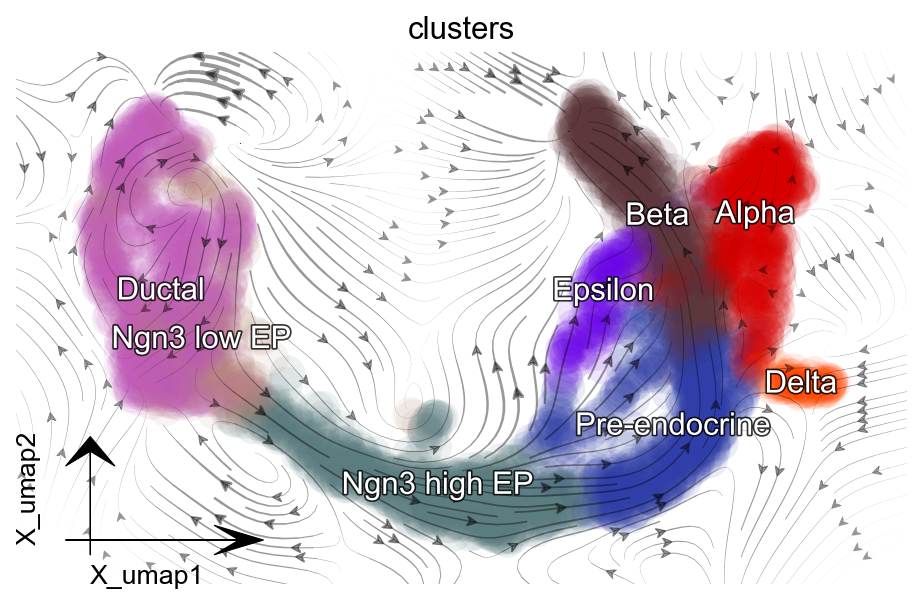

In [5]:
dyn.pl.topography(adata, color=['clusters'], basis='umap', background='white',
                  streamline_color='black', #color_key = pancreas_cluster_cmap,
                  show_legend='on data', terms=("streamline"))


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


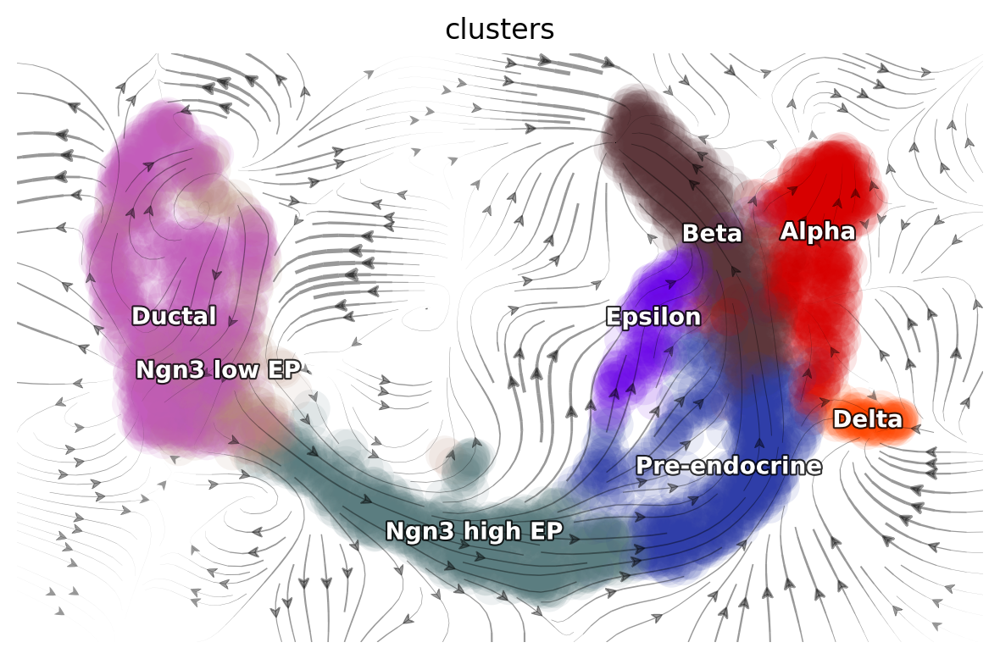

In [20]:
dyn.pl.topography(adata, color=['clusters'], basis='umap', background='white',
                  streamline_color='black', #color_key = pancreas_cluster_cmap,
                  show_legend='on data', terms=("streamline"))


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


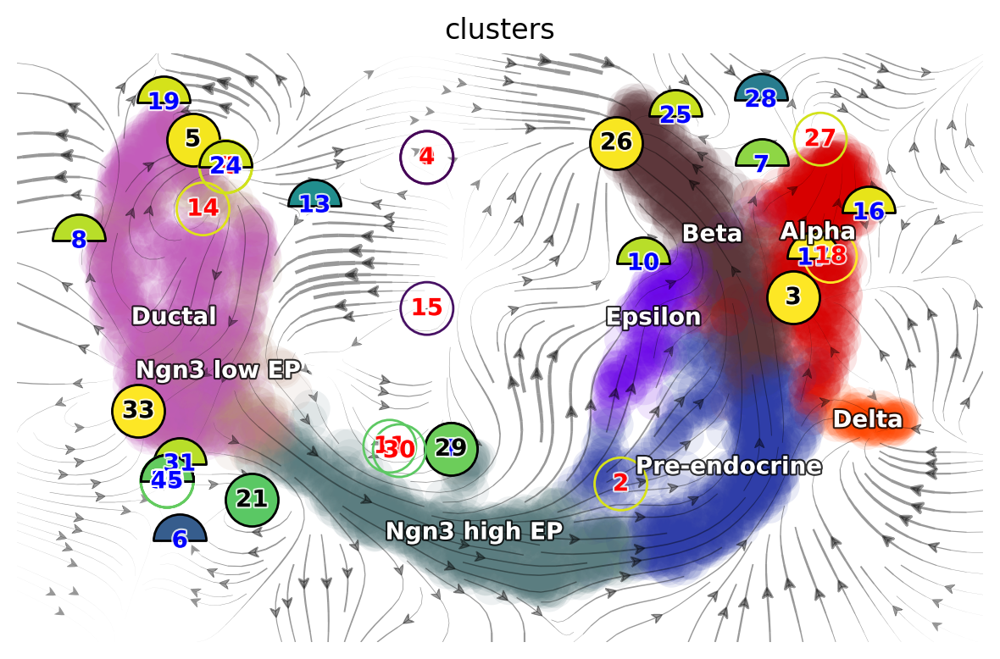

In [21]:
dyn.pl.topography(
    adata,
    markersize=500,
    basis="umap",
    fps_basis="umap",
    #color_key = pancreas_cluster_cmap,
    color=["clusters"],
    show_legend='on data',
    save_show_or_return='show'
)

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


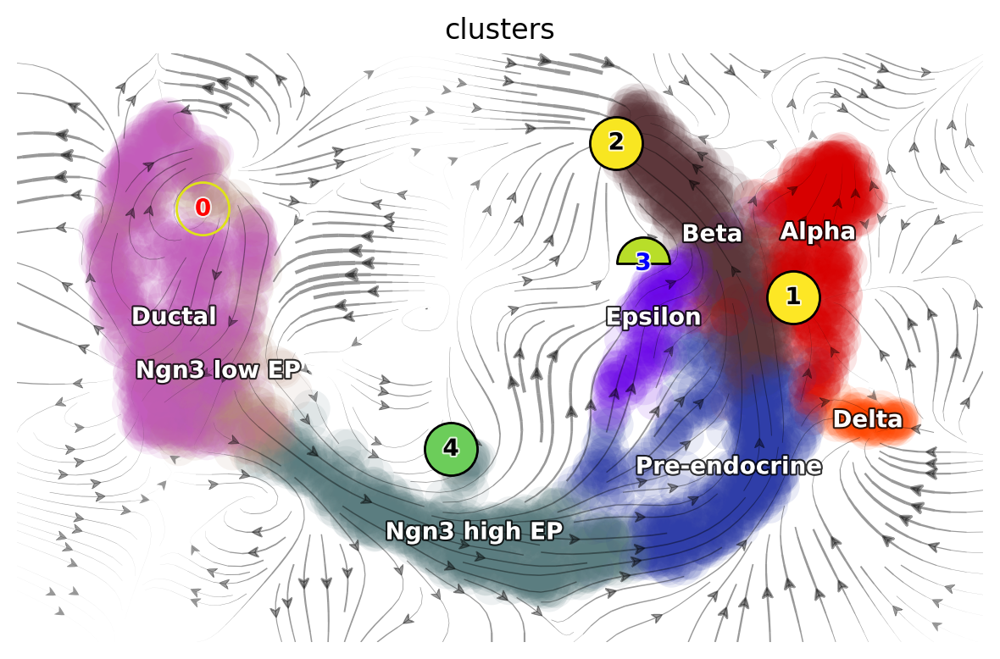

In [23]:
adata_load_fix_points=adata.copy()
Xss, ftype, conf = adata_load_fix_points.uns['VecFld_umap']['Xss'],\
                   adata_load_fix_points.uns['VecFld_umap']['ftype'],\
                   adata_load_fix_points.uns['VecFld_umap']['confidence']

fixed_points = [14,3,26,10,29]

adata_load_fix_points.uns['VecFld_umap']['Xss'] = Xss[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['ftype'] = ftype[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['confidence']=conf[fixed_points]

dyn.pl.topography(
    adata_load_fix_points,
    markersize=500,
    basis="umap",
    fps_basis="umap",
    #color_key = pancreas_cluster_cmap,
    color=["clusters"],
    show_legend='on data',
    save_show_or_return='show'
)

In [19]:
dyn.tl.cell_velocities(adata, basis="umap")

Using existing pearson_transition_matrix found in .obsp.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.1010s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase', 'umap_ddhodge_div', 'umap_ddhodge_potential', 'curl_umap', 'divergence_umap', 'control_point_umap', 'inlier_prob_umap', 'obs_vf_angle_umap'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'score', 'log_m', 'log_cv', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'grid_velocity_umap', 'VecFld_umap'
    obsm: 'X

In [20]:
dyn.tl.cell_velocities(adata, basis="pca")
dyn.vf.VectorField(adata, basis='pca') 

Using existing pearson_transition_matrix found in .obsp.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.3342s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: PCA. 
        Vector field will be learned in the PCA space.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [SparseVFC] completed [3.5454s]
|-----> [VectorField] completed [3.7791s]


Transforming subset Jacobian: 100%|██████████| 3696/3696 [00:00<00:00, 98211.83it/s]


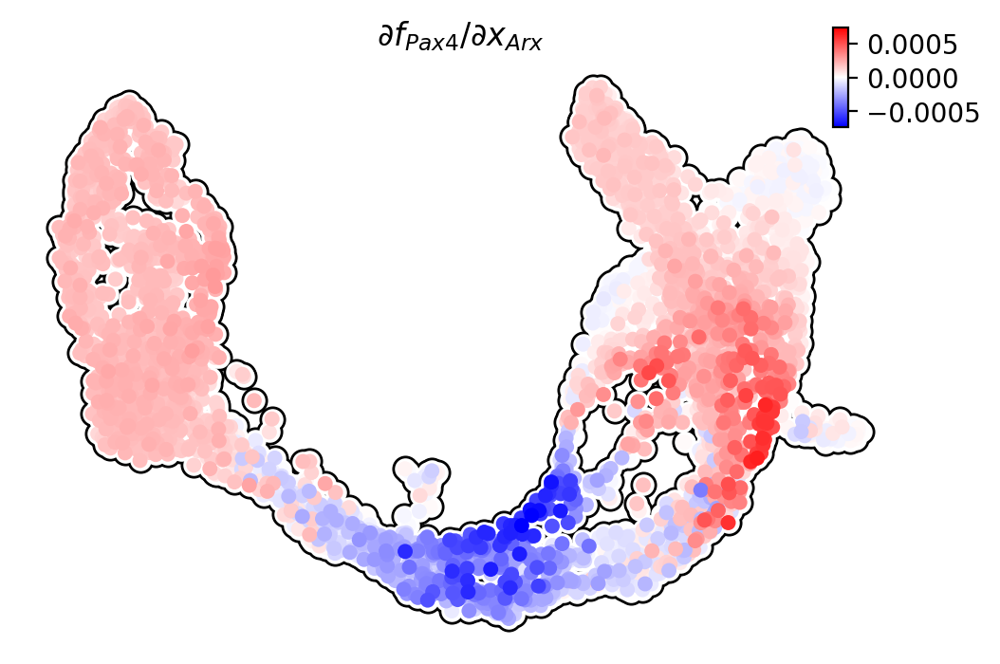

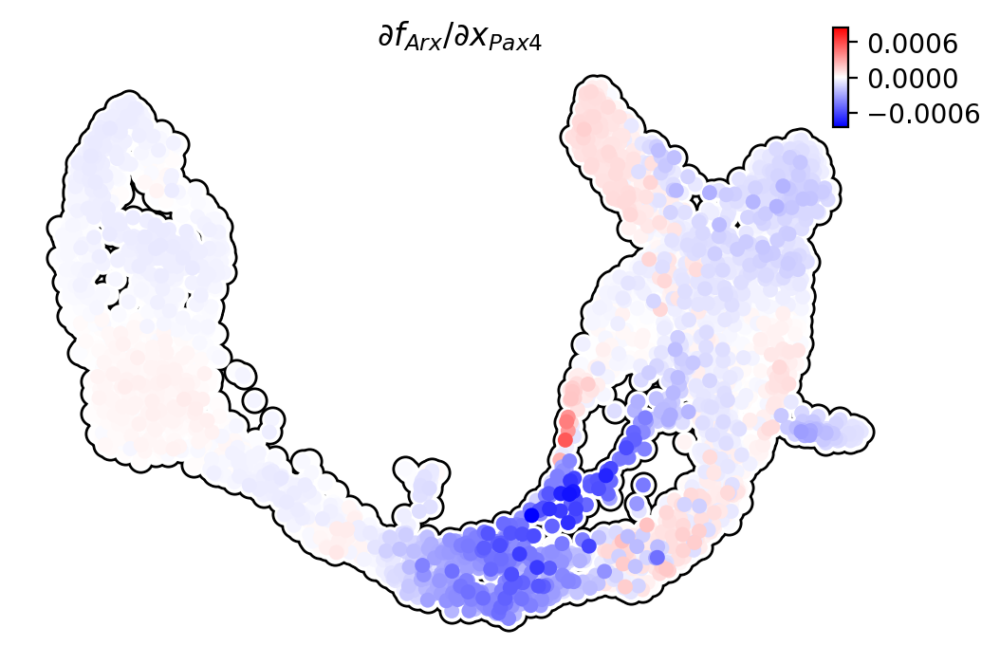

In [21]:
dyn.vf.jacobian(adata, regulators=['Arx','Pax4'])

dyn.pl.jacobian(
    adata,
    basis="umap",
    regulators=['Arx'],
    effectors=['Pax4'],
    alpha=1,
)

dyn.pl.jacobian(
    adata,
    basis="umap",
    regulators=['Pax4'],
    effectors=['Arx'],
    alpha=1,
)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


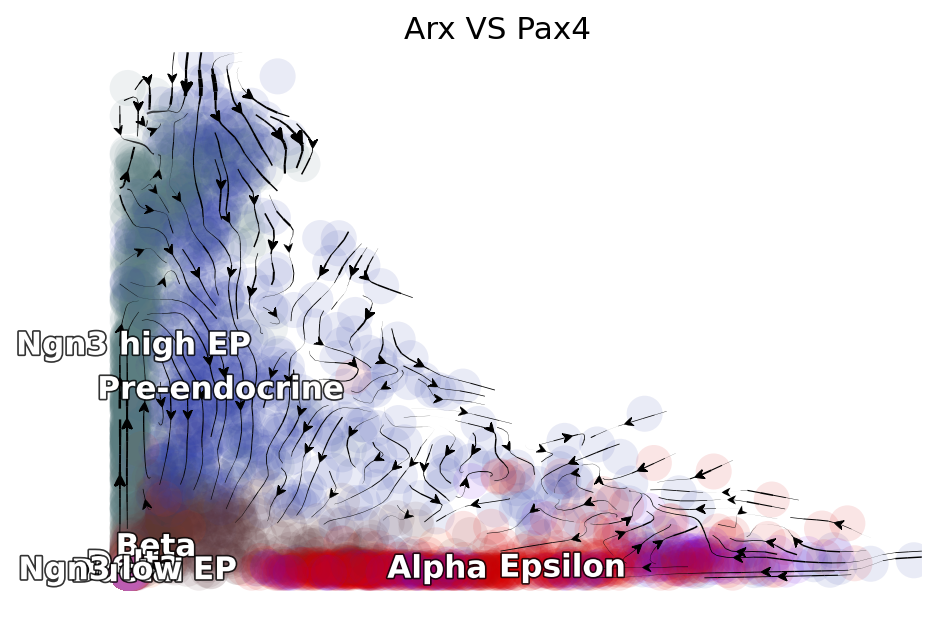

In [22]:
%matplotlib inline
dyn.pl.style()
dyn.pl.streamline_plot(
    adata,
    color="clusters",
    x="Arx",
    y="Pax4",
    layer="M_s",
    ekey="M_s",
    #vkey="velocity_alpha_minus_gamma_s",
)

|-----------> plotting with basis key=X_umap
|-----------> plotting with basis key=X_umap


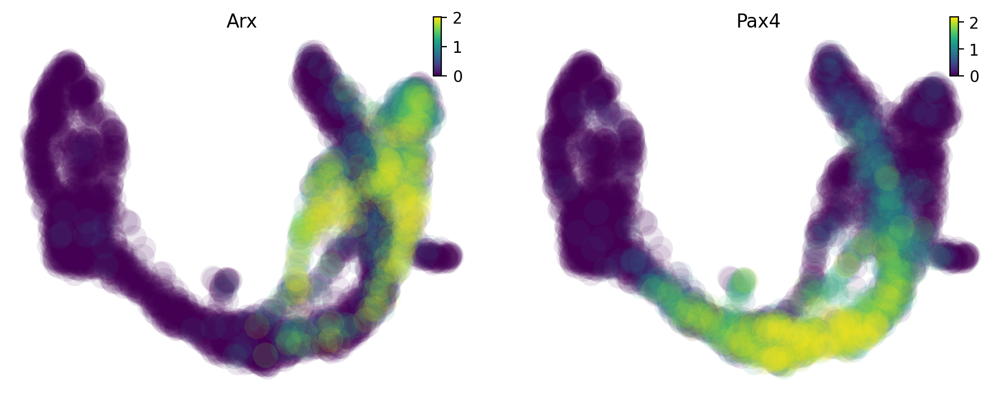

In [23]:
dyn.pl.umap(adata,  color=["Arx",'Pax4'],save_show_or_return='show')

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


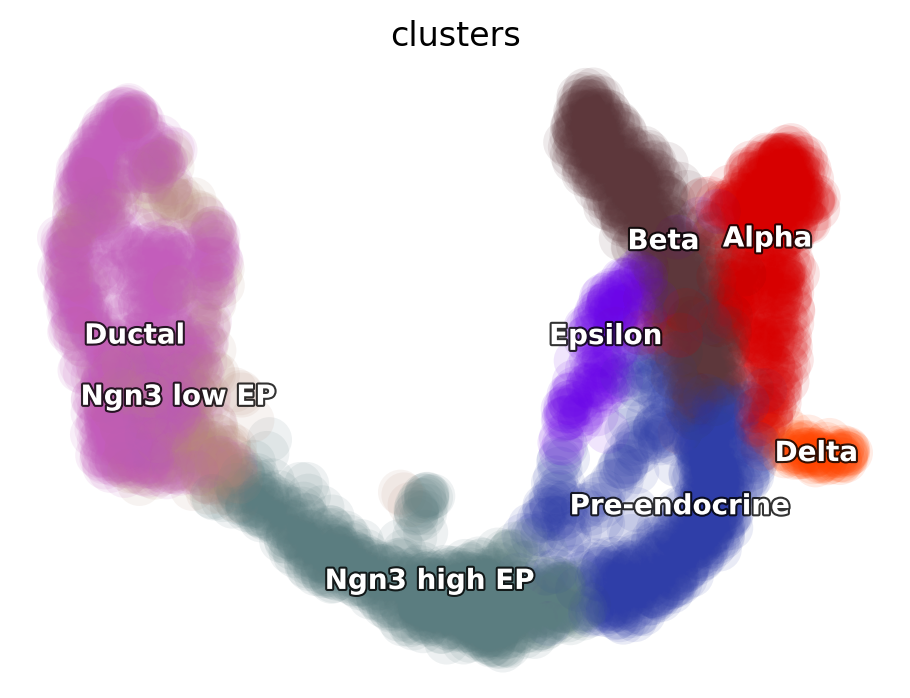

In [24]:
dyn.pl.umap(adata,
               color='clusters',)

In [4]:
pancreas_cluster_cmap = {'Ductal': '#3361A5',
                         'Ngn3 low EP': '#248AF3',
                         'Ngn3 high EP': '#14B3FF',
                         'Pre-endocrine': '#88CEEF',
                         'Alpha': '#ff4800',
                         'Beta': '#B81136',
                         'Delta': 'green',
                         'Epsilon': '#03B3B0'}


In [20]:
color_dict=dict(zip(
    adata.obs['clusters'].cat.categories,
    adata.uns['clusters_colors']
))

In [27]:
adata.obs['clusters'].cat.categories

Index(['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine', 'Beta',
       'Alpha', 'Delta', 'Epsilon'],
      dtype='object')

In [73]:
dyn.pl.style()

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


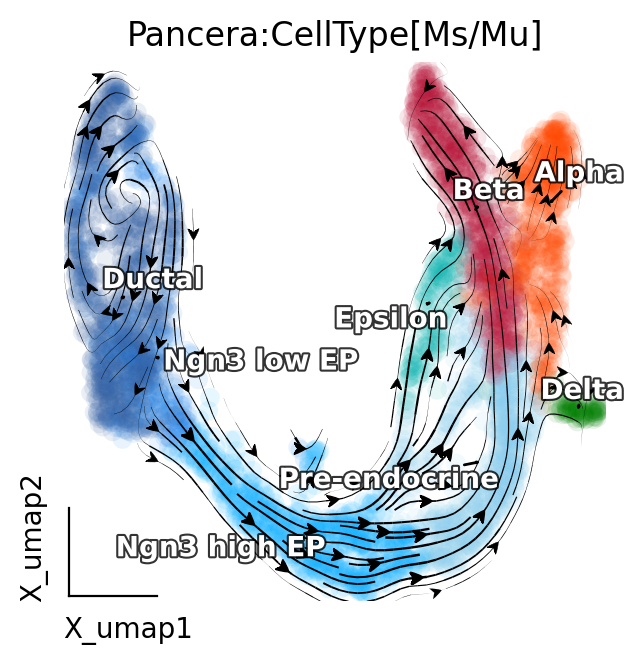

In [75]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       color_key=pancreas_cluster_cmap,
                       title='Pancera:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('Pancrea:CellType[Ms/Mu]',fontsize=12)

coords=adata_load_fix_points.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

#ax.xaxis.set_label_coords(0.07, 0.07)
#ax.yaxis.set_label_coords(0.07, 0.07)
fig.savefig(f'figures/fig3/Ms_Mu_HSC_Velo.png', dpi=300, bbox_inches='tight')

In [20]:
# you can set `verbose = 1/2/3` to obtain different levels of running information of vector field reconstruction
dyn.vf.VectorField(adata, basis='umap', M=100, pot_curl_div=True) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [6.2780s]
|-----> Running ddhodge to estimate vector field based pseudotime in umap basis...
|-----> fetch computation results from adata.obsp[umap_ddhodge]...
|-----> [ddhodge completed] completed [13.0575s]
|-----> Computing curl...


Calculating 2-D curl: 100%|██████████| 3696/3696 [00:00<00:00, 19937.81it/s]

|-----> Computing divergence...



Calculating divergence: 100%|██████████| 4/4 [00:00<00:00, 24.33it/s]


|-----> [VectorField] completed [20.0033s]


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'Pancera:Topography[Ms/Mu]')

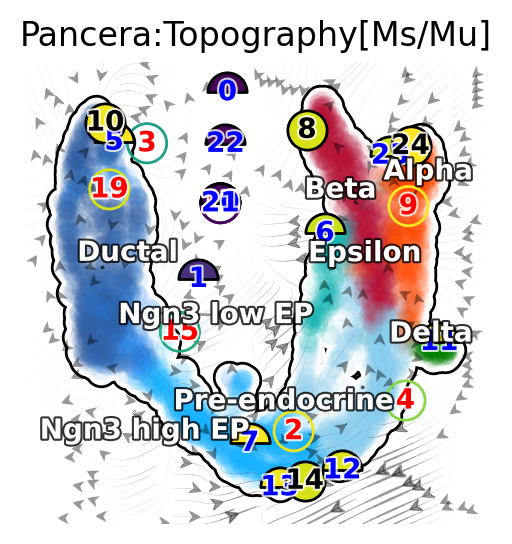

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'clusters'], 
                  color_key=pancreas_cluster_cmap,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('Pancrea:Topography[Ms/Mu]',fontsize=12)

coords=adata_load_fix_points.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Topography.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


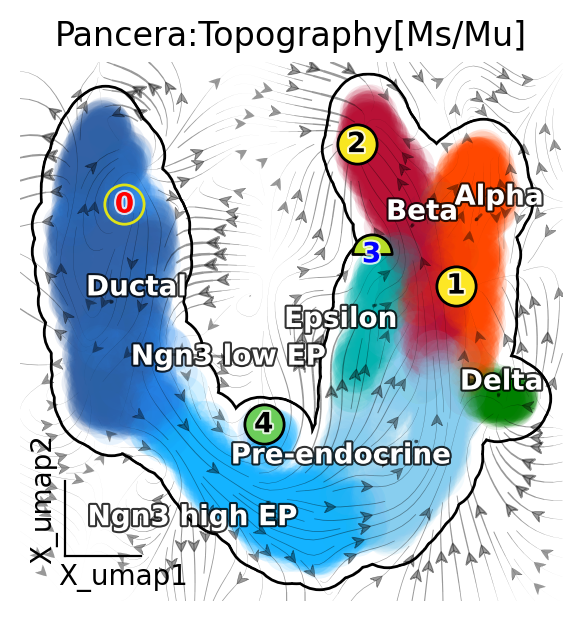

In [70]:
adata_load_fix_points=adata.copy()
Xss, ftype, conf = adata_load_fix_points.uns['VecFld_umap']['Xss'],\
                   adata_load_fix_points.uns['VecFld_umap']['ftype'],\
                   adata_load_fix_points.uns['VecFld_umap']['confidence']

fixed_points = [14,3,26,10,29]

adata_load_fix_points.uns['VecFld_umap']['Xss'] = Xss[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['ftype'] = ftype[fixed_points]
adata_load_fix_points.uns['VecFld_umap']['confidence']=conf[fixed_points]

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
#ov.plot_set()
dyn.pl.topography(adata_load_fix_points, basis='umap',
                  fps_basis='umap',background='white', 
                  color=[ 'clusters'], 
                  color_key=pancreas_cluster_cmap,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('Pancrea:Topography[Ms/Mu]',fontsize=12)

coords=adata_load_fix_points.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)
fig.savefig(f'figures/fig3/Ms_Mu_HSC_Topography.png', dpi=300, bbox_inches='tight')
fig

|-----------> plotting with basis key=X_umap


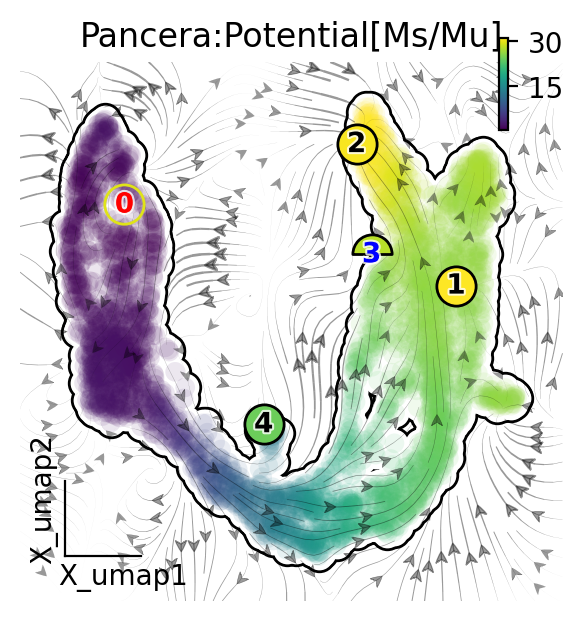

In [66]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3.5,3.5))
dyn.pl.topography(adata_load_fix_points, basis='umap', background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  frameon=True,
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('Pancrea:Potential[Ms/Mu]',fontsize=12)
ax.axis(True)
#fig.axis.visible = True
coords=adata_load_fix_points.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

ax.xaxis.set_label_coords(0.07, 0.07)
ax.yaxis.set_label_coords(0.07, 0.07)


fig.savefig(f'figures/fig3/Ms_Mu_HSC_Potential.png', dpi=300, bbox_inches='tight')

In [76]:
adata.write('data/rna_pp/pancrea_msmu_visual.h5ad')

In [3]:
adata=dyn.read('data/rna_pp/pancrea_msmu_visual.h5ad')